# 실습코드

In [1]:
from tensorflow import keras

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
print(train_target[0])
print(train_input[0])

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 

In [5]:
train_scaled = train_input/255.0
train_scaled = train_scaled.reshape(-1,28*28)

test_scaled = test_input / 255.0
test_scaled = test_scaled.reshape(-1,28*28)

In [6]:
train_scaled.shape, test_scaled.shape

((60000, 784), (10000, 784))

In [7]:
from tensorflow.keras.utils import to_categorical
train_target = to_categorical(train_target)
test_target = to_categorical(test_target)

In [8]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size = 0.2, random_state=42)

In [9]:
train_scaled.shape, val_scaled.shape, train_target.shape, val_target.shape

((48000, 784), (12000, 784), (48000, 10), (12000, 10))

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input

model = Sequential()

model.add(Input(shape=(784,)))
model.add(Dense(100, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)
model.fit(train_scaled, train_target, epochs = 50, validation_data = (val_scaled, val_target))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8653 - loss: 0.4976 - val_accuracy: 0.9544 - val_loss: 0.1616
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9594 - loss: 0.1433 - val_accuracy: 0.9640 - val_loss: 0.1178
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9724 - loss: 0.0932 - val_accuracy: 0.9671 - val_loss: 0.1076
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9790 - loss: 0.0700 - val_accuracy: 0.9701 - val_loss: 0.1012
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9832 - loss: 0.0542 - val_accuracy: 0.9729 - val_loss: 0.0877
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9740 - val_loss: 0.0865
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9891 - loss: 0.0357 - val_accuracy: 0.9716 - val_loss: 0.0999
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9914 - loss: 0.0297 - 

In [22]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [23]:
model.evaluate(test_scaled,test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9719 - loss: 0.1826


[0.15879467129707336, 0.9761000275611877]

# 개념정리

- Sequential :  레이어을 하나씩 연결하여 모델을 구성할 수 있게 해주는 클래스
## 모델 구축 순서


- keras.models에서 Sequential 클래스를 가져온다.
- add() 메서드를 이용해 레이러를 쌓는다.
- compile()메서드를 사용해 학습 과정을 구성한다.
- fit()메서드를 사용해 학습 과정을 구성한다.
- model.evaluate(X_test, y_test, batch_size=32)

- Dense : 완결 연결층, 입력층과 출력층이 모두 연결되어 있는 것을 의미
- 첫번째 위치 인자(Positional Argument) : 출력 노두 수 (뉴런수)
- activation
  - linear : 디폴트 값으로 별도 활성화함수 없이 입력 뉴련과 가중치의 계산 결과 그대로 출력.
  - sigmoid : 이진 분류 문제에서 출력층에 주로 사용되는 활성화함수
  - relu : 셋 이상의 선택지 중 하나를 택한느 다중 클래스 분류 문제에서 출력층에 주로 사용되는 활성화 함수
- Input_dim : 자료의 특성 개수를 의미하며, 보통 DataFrame의 Columns 개수와 일치.
  - 예> MNIST의 경우 784(28*28)이 된다.

## 컴파일


Complie() : 모델을 기계가 이해할 수 있도록 컴파일 합니다. 손실함수와 옵티마이저, 메트릭 함수를 선택합니다.
```
model.compie(optimizer = 'rmsprop', loss='binary_croossentropy', merics=['accuracy'])
```
- optimizer : 훈련과정을 설정하는 옵티마이저를 설정합니다.
- loss : 훈련과정에서 사용할 손실함수 (loss function)을 설정합니다.
- metrics : 훈련을 모니터링하기 위한 지표를 선택합니다.
  
  <br>

- 경사하강법
- 확률적 경사하강법(SGD)
: 확률적으로 무작위로 골라낸 데이터에 대해 수행하는 경사하강법, 미니배치를 사용해 무작위로 선정한 데이터에 대해 경사 하강법을 쓰기 때문임.
  
<br>

- 모맨텀 : 국소 최소접을 벗어날 수 있도로 SGD 식에 가중치의 1차식을 더해준 방식
- Adagrad : 고정된 학습률이 아닌 변화하는 학습률을 사용하게 해주는 옵티마이저
- rmsprop : Adagrad에서 학습률이 줄어드는 문제를 해결하기 위한 옵팀아ㅣ저
- Adam : 모맨텀 + AdaGrad  

|문제유형|솔실 함수명|출력층의 활성화 함수명|
|---|---|---|
|회귀문제|mean_squared_error|-|
|다중 클래스 분류|categorical_crossentropy|소프트 맥스|
|다중 클래스 분류|sparse_categorical_crossentropy|소프트 맥스|
|이진 분류|binary_crossentropy|시그모이드|

## fit:훈련시키기

`fit()`: 모델을 학습합니다.

* **첫 번째 인자** = 훈련 데이터에 해당됩니다.
* **두 번째 인자** = 지도 학습에서 레이블 데이터에 해당됩니다.
* **`epochs`** = 에포크. 1 에포크는 전체 데이터를 한 차례 훑고 지나갔음을 의미함. 정수값 기재 필요. 총 훈련 횟수를 정의합니다.
* **`batch_size`** = 배치 크기. 기본값은 **32**. 미니 배치 경사 하강법을 사용하고 싶지 않을 경우에는 `batch_size=None`을 기재합니다.


* **batch (배치)**
    * 전체 데이터 중 일부만 취하는 것.
    * *예시> 20000개 중 100개만 취했을 경우, 100이 batch의 크기이다.*
* **epoch (에포크)**
    * 전체 데이터를 모두 학습에 1번 사용할 때까지 걸린 반복 횟수.

> **즉,** 전체 데이터 개수가 **20000개**이고, **`batch` = 500** 이면, **1 epoch**는 **4** 이다.
> (*계산: 20000 / 500 = 4*)

- verbose : 학습 중 출력되는 문구를 설정합니다
  - 0 : 아무것도 출력하지 않습니다.
  - 1 : 훈련의 진행도를 보여주는 진행 막대를 보여줍니다.
  - 2 : 미니 배치마다 손실 정보를 출력합니다.

## 평가(Evaluation)와 예측(Prediction)

evaluate() : 테스트 데이터를 통해 학습한 모델에 대한 정확도를 평가합니다.
  - 첫번째 인자 = 데이터에 해당
  - 두번재 인자 = 지도 학습에서 레이블 테스트 데이터에 해당
  - batch_size = 배치 크기

predict() = 임의의 입력에 대한 모델의 출력값을 확인
  - 첫번째 인자 = 예측하고자 하는 데이터
  - batch_size = 배치 크기

## 모델 저장(save)과 로드(Load)

save() : 인공 신경망 모델을 hdf5파일에 저장합니다.  
load_model() : 저장해둔 모델을 불러옵니다.

# 코드

In [14]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [15]:
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [16]:
train_target.shape, train_input.shape, test_target.shape, test_input.shape

((60000,), (60000, 28, 28), (10000,), (10000, 28, 28))

In [39]:
train_target.dtype

dtype('uint8')

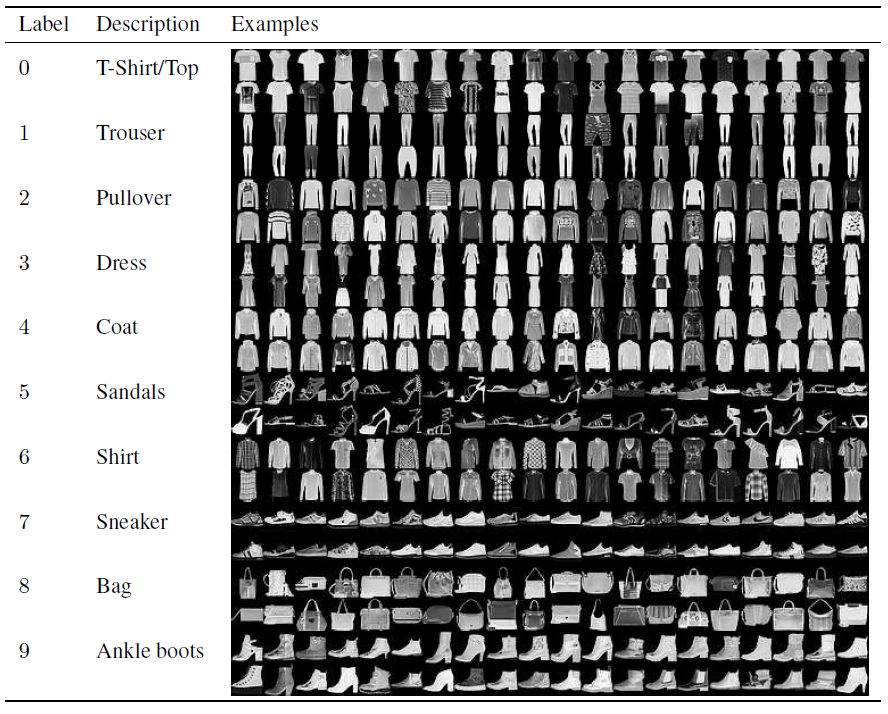

In [17]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [19]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

In [20]:
train_scaled.shape

(60000, 784)

In [21]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size = 0.1, random_state = 42)

In [22]:
train_scaled.shape, val_scaled.shape, train_target.shape, val_target.shape

((54000, 784), (6000, 784), (54000,), (6000,))

In [26]:
dense = keras.layers.Dense(10, activation='softmax', input_shape=(784,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model = keras.Sequential([dense])

In [36]:
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [37]:
model.fit(train_scaled, train_target, epochs = 5)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7422 - loss: 0.7711
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8363 - loss: 0.4803
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8474 - loss: 0.4520
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8529 - loss: 0.4382
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8559 - loss: 0.4296


In [38]:
model.evaluate(val_scaled, val_target)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8496 - loss: 0.4278


[0.4401940107345581, 0.843999981880188]

# 실습해보기

In [44]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [51]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [53]:
# train_scaled = train_input / 255.0
# test_scaled = test_input / 255.0
import numpy as np

# 정규화를 하기 위해 학습 데이터의 평균과 분산 구하기
mean = np.mean(train_input)
std  = np.std(train_input)

# 데이터 정규화하기
# 0으로 나눠지는 것 (=무한대로 수렴)을 막기 위해 1e-7 더기기
train_sacled = (train_input-mean)/(std+1e-7)
test_scaled  = (test_input-mean) /(std+1e-7)


In [54]:
from keras.layers import Flatten
from keras.layers import Dense
from keras.models import Sequential

model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

model.fit(train_scaled, train_target, validation_split=0.1, epochs = 5, verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7687 - loss: 0.6539 - val_accuracy: 0.8493 - val_loss: 0.4334
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8581 - loss: 0.3982 - val_accuracy: 0.8697 - val_loss: 0.3794
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8722 - loss: 0.3524 - val_accuracy: 0.8723 - val_loss: 0.3591
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8822 - loss: 0.3282 - val_accuracy: 0.8750 - val_loss: 0.3573
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8891 - loss: 0.3112 - val_accuracy: 0.8788 - val_loss: 0.3627


In [49]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.60 KB)

In [50]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.3785


[0.3850618302822113, 0.8730999827384949]